#### Importing Dependencies


In [1]:
import sys
import os
# Add parent directory ('notebooks') to the search path
sys.path.append(os.path.abspath(os.path.join('..')))


from pydantic import BaseModel, Field

from qdrant_client import QdrantClient
from qdrant_client.models import Prefetch, Filter, FieldCondition, MatchText, FusionQuery, Document

from langsmith import traceable, get_current_run_tree

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.types import Send, Command
from langsmith import traceable

from langchain_core.messages import AIMessage, ToolMessage

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List, Optional, Sequence
from IPython.display import Image, display
from operator import add
from openai import OpenAI

import openai

import random
import ast
import inspect
import instructor
import json


sys.path.append(os.path.abspath(os.path.join('..')))
from utils.utils import get_tool_descriptions, format_ai_message


from qdrant_client import QdrantClient
from qdrant_client.models import VectorParams, Distance, PayloadSchemaType, PointStruct, SparseVectorParams, Document, Prefetch, FusionQuery
from qdrant_client import models

import pandas as pd
import openai
import fastembed



from typing import Annotated, Any, Dict, List
from operator import add
from pydantic import BaseModel, Field


/Users/pritam/Desktop/AI-Engineering/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
from qdrant_client import QdrantClient
qdrant_client = QdrantClient(url="http://localhost:6333")

#### Retriever

In [19]:
@traceable(
    name="get_embedding",
    run_type="embedding",
    metadata={
        "ls_model": "openai/text-embedding-3-small",
        "ls_provider": "openai",
        "ls_model_type": "embedding"
        }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=[text],
        model=model,
    )
    return response.data[0].embedding


    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata['usage_metadata'] = {
            'prompt_tokens': response.usage.prompt_tokens,
            'completion_tokens': getattr(response.usage, 'completion_tokens', 0),
            'total_tokens': response.usage.total_tokens
        }

        
    return response.data[0].embedding

@traceable(
    name="retrieve_products_data",
    run_type="retriever",
    metadata={
        "ls_provider": "qdrant",

    }
)
def retrieve_products_data(query: str, limit: int = 3):
    """
    Search for products based on a natural language query.
    """
    # 1. Convert the user's text query into a vector embedding
    query_vector = get_embedding(query)
    
    # 2. Search the Qdrant database for the closest matching vectors
    search_results = qdrant_client.query_points(
        collection_name="Products-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_vector,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )
        ],
        query=FusionQuery(fusion="rrf"),
        limit=limit
    )


    retrieve_context = []
    average_rating = []
    similarity_score = []
    context_id = []

    for result in search_results.points:
        # Extract fields from the payload and the Qdrant result object
        retrieve_context.append(result.payload["description"])
        average_rating.append(result.payload["average_rating"])
        similarity_score.append(result.score)
        context_id.append(result.payload["parent_asin"])
        
    return {
        "retrieved_context": retrieve_context,
        "retrieved_context_ratings": average_rating,
        "similarity_score": similarity_score,
        "retrieved_context_ids": context_id
    }

def process_context(context):
    formatted_context = ""
    
    for id, chunk, rating in zip(context["retrieved_context_ids"], context["retrieved_context"], context["retrieved_context_ratings"]):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"
        
    return formatted_context



/Users/pritam/Desktop/AI-Engineering/.venv/lib/python3.12/site-packages/qdrant_client/qdrant_remote.py:290: UserWarning: Failed to obtain server version. Unable to check client-server compatibility. Set check_compatibility=False to skip version check.
  show_warning(


In [20]:
def get_formatted_context(query: str, top_k: int = 5) -> str:
    """Get the top k context, each representing an inventory item for a given query.

    Args:
        query: The query to get the top k context for
        top_k: The number of context chunks to retrieve, works best with 5 or more

    Returns:
        A string of the top k context chunks with IDs and average ratings prepending each chunk.
    """
    # Annotate the variable type correctly:
    context: dict[str, list] = retrieve_products_data(query, limit=top_k)
    formatted_context = process_context(context)
    
    return formatted_context


### State and Pydantic model for Structured outputs

In [21]:

class ToolCall(BaseModel):
    name: str
    arguments: Dict[str, Any]  # Typing dict[str, Any] is preferred over generic dict


class RAGUsedContext(BaseModel):
    id: str = Field(
        description="The ID of the item used to answer the question"
    )
    description: str = Field(
        description="Short description of the item used to answer the question"
    )


class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    question_relevant: bool = False
    iteration: int = 0
    answer: str = ""
    available_tools: List[Dict[str, Any]] = []
    tool_calls: List[ToolCall] = []
    final_answer: bool = False
    references: Annotated[List[RAGUsedContext], add] = []


#### Agent Node

In [22]:
# Definition of the structured output model required by the LLM
class AgentResponse(BaseModel):
    answer: str = Field(
        description="The answer to the question based on your current knowledge and the tool results. "
                    "Should contain detailed product specs in bullet points."
    )
    tool_calls: List[ToolCall] = Field(
        description="The list of tool calls to make if more information is needed. Should be empty if final_answer is True."
    )
    final_answer: bool = Field(
        description="True if you have all the information needed to answer the question, False otherwise."
    )
    references: List[RAGUsedContext] = Field(
        description="List of references from the retrieved context used to compile the answer."
    )

In [23]:
from langchain_core.messages import convert_to_openai_messages

@traceable(
    name="agent_node",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4o-mini"} # Fixed typo 'gpt-4.1-mini' -> 'gpt-4o-mini'
)
def agent_node(state: State) -> dict:
    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.
You will be given a conversation history and a list of tools you can use to answer the latest query.
<Available tools>
{{ available_tools | tojson }}
</Available tools>
When making tool calls, use this exact format:
{
    "name": "tool_name",
    "arguments": {
        "parameter1": "value1",
        "parameter2": "value2"
    }
}
CRITICAL: All parameters must go inside the "arguments" object, not at the top level of the tool call.
Examples:
- Get formatted item context:
{
    "name": "get_formatted_item_context",
    "arguments": {
        "query": "cool kids toys.",
        "top_k": 5
    }
}
CRITICAL RULES:
- If tool_calls has values, final_answer MUST be false
  (You cannot call tools and exit the graph in the same response)
- If final_answer is true, tool_calls MUST be []
  (You must wait for tool results before exiting the graph)
- If you need tool results before answering, set:
  tool_calls=[...], final_answer=false
- After receiving tool results, you can then set:
  tool_calls=[], final_answer=true
- Use names specifically provided in the available tools. Don't add any additional text to the names.
Instructions:
- You need to answer the question based on the outputs from the tools using the available tools only.
- Do not suggest the same tool call more than once.
- If the question can be decomposed into multiple sub-questions, suggest all of them.
- If multiple tool calls can be used at once to answer the question, suggest all of them.
- Do not explain your next steps in the answer, instead use tools to answer the question.
- Never use word context and refer to it as the available products.
- You should only answer questions about the products in stock. If the question is not about the products in stock, you should ask for clarification.
- As an output you need to return the following:
* answer: The answer to the question based on your current knowledge and the tool results.
* references: The list of the indexes from the chunks returned from all tool calls that were used to answer the question. If more than one chunk was used to compile the answer from a single tool call, be sure to return all of them.
* Each reference should have an id and a short description of the item based on the retrieved context.
* final_answer: True if you have all the information needed to provide a complete answer, False otherwise.
- The answer to the question should contain detailed information about the product and should be returned with detailed specification in bullet points.
- The short description should have the name of the item.
- If the user's request requires using a tool, set tool_calls with the appropriate function names and arguments.
"""
    template = Template(prompt_template)
    prompt = template.render(
        available_tools=state.available_tools
    )
    # Fixed typo: 'state.eessages' -> 'state.messages'
    messages = state.messages
    conversation = []
    for message in messages:
        conversation.append(convert_to_openai_messages(message))
    client = instructor.from_openai(OpenAI())
    response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4o-mini",
        response_model=AgentResponse,
        messages=[{"role": "system", "content": prompt}, *conversation],
        temperature=0.5,
    )
    ai_message = format_ai_message(response)
    return {
        "messages": [ai_message],
        "tool_calls": response.tool_calls,
        "iteration": state.iteration + 1,
        "answer": response.answer,
        "final_answer": response.final_answer,
        "references": response.references
    }

In [24]:
def tool_router(state: State) -> str:
    """Decide whether to continue or end"""

    if state.final_answer:
        return "end"
    elif state.iteration > 2:
        return "end"
    elif len(state.tool_calls) > 0:
        return "tools"
    else:
        return "end"

In [36]:


class IntentRouterResponse(BaseModel):
    question_relevant: bool = Field(
        description="True if the question is relevant to products, product discovery, or shopping. False otherwise."
    )
    answer: str = Field(
        description="Brief explanation of why the question is not relevant (only set if question_relevant is False, otherwise leave empty '')."
    )




@traceable(
    name="intent_router_node",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4o-mini"} # Fixed 'gpt-4.1-mini' -> 'gpt-4o-mini'
)
def intent_router_node(state: State):
    prompt_template = """You are part of a shopping assistant that can answer questions about products in stock.
Instructions:
- You will be given a question and you need to classify it into relevant or not relevant.
- If the question is not relevant, return False in field "question_relevant" and set "answer" to explanation why it is not relevant.
- If the question is relevant, return True in field "question_relevant" and set "answer" to "".
- You should only answer questions about the products in stock. If the question is not about the products in stock, you should ask for clarification.
<Question>
{{ query }}
</Question>
"""

    first_message = state.messages[0]
    query = first_message.content if hasattr(first_message, "content") else first_message.get("content", "")


    template = Template(prompt_template)
    prompt = template.render(
        query=query
    )
    client = instructor.from_openai(OpenAI())
    response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4o-mini", # Fixed 'gpt-4.1-mini' -> 'gpt-4o-mini'
        response_model=IntentRouterResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
    )
    return {
        "question_relevant": response.question_relevant,
        "answer": response.answer
    }

In [37]:

def intent_router_conditional_edges(state: State) -> str:
    return "agent_node" if state.question_relevant else "end"


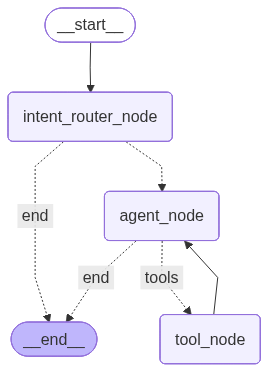

In [38]:
workflow = StateGraph(State)

tools = [get_formatted_context]
tools_node = ToolNode(tools)
tools_description = get_tool_descriptions(tools)

workflow.add_node("agent_node",agent_node)
workflow.add_node("tool_node",tools_node)
workflow.add_node("intent_router_node",intent_router_node)


workflow.add_edge(START,"intent_router_node")
workflow.add_conditional_edges("intent_router_node",
intent_router_conditional_edges,
{
    "agent_node":"agent_node",
    "end":END
})
workflow.add_conditional_edges("agent_node",
tool_router,{
"tools":"tool_node",
"end":END
})


workflow.add_edge("tool_node","agent_node")


graph = workflow.compile()


display(Image(graph.get_graph().draw_mermaid_png()))


In [39]:
# A realistic test query that directly matches the John Frieda and Garnier products in your dataset
initial_state = {
    "messages": [{
        "role": "user", 
        "content": "Do you have any coconut oil shampoos for frizzy hair, or a color sealer leave-in conditioner?"
    }],
    "available_tools": tools_description
}


In [42]:
result = graph.invoke(initial_state)

In [44]:
print(result["answer"])

Here are the products I found for you:

### Coconut Oil Shampoos for Frizzy Hair:
1. **John Frieda Coconut Oil Infused Frizz Ease Shampoo**  
   - **Rating:** 4.5  
   - **Description:** Formulated to build up resistance to dry, damaged, frizzy hair while making it more manageable and easily styled. Infused with coconut oil, it gently cleanses and helps fight frizz and flyaways. 
   - **Benefits:** Repairs and moisturizes damaged, curly, frizzy, and coarse hair types; reduces frizz by up to 90% with continuous use.
   - **ID:** B086HRN773

2. **Yves Rocher Monoi de Tahiti Lagoon Hair and Body Wash**  
   - **Rating:** 4.3  
   - **Description:** Contains Monoï de Tahiti, a natural botanical elixir that enhances hair and skin beauty. It helps eliminate salt and sand from hair after beach use and tightens hair fibers for added brilliance. 
   - **ID:** B01CQ1KPCS

### Color Sealer Leave-In Conditioners:
1. **Garnier Fructis Color Shield Instant Color Sealer**  
   - **Rating:** 4.4  
   